# Spiral-Serialized LSTM — 20-Way Coarse CIFAR-100

An LSTM that reads each image along an **outside→center spiral** (not row by row) and classifies
it into one of the **20 coarse superclasses**. The spiral is the one variable under test: pixels
enter in spiral order, the tensor stays `(32 timesteps, 96 features)`, the model is a plain LSTM.

This run **actually trains** (no smoke-test shortcut) and includes visualizations of the data, the
spiral reading order on a real image, the learning curves, the confusion matrix, and sample
predictions. Self-contained: no local imports, runs top-to-bottom in Colab (T4 GPU recommended).


## 1. Setup

In [1]:
import subprocess
import sys


def _ensure(module_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or module_name])


_ensure("datasets")
_ensure("sklearn", "scikit-learn")
_ensure("matplotlib")

In [2]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    top_k_accuracy_score,
)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("tensorflow:", tf.__version__)

tensorflow: 2.20.0


In [3]:
# --- Run configuration (this trains for real) ---
NUM_CLASSES = 20          # CIFAR-100 coarse superclasses
SUBSET      = 20000       # train-set size used. Set None for the full 50k (final run); ~5000 to debug.
EPOCHS      = 30          # EarlyStopping usually stops before this
BATCH       = 128
HIDDEN      = 128
DROPOUT     = 0.3
LR          = 1e-3
print(f"classes={NUM_CLASSES}  subset={SUBSET}  epochs={EPOCHS}  batch={BATCH}")

classes=20  subset=20000  epochs=30  batch=128


## 2. Load CIFAR-100

In [4]:
ds = load_dataset("uoft-cs/cifar100")
train_split, test_split = ds["train"], ds["test"]
coarse_names = train_split.features["coarse_label"].names


def split_to_arrays(split):
    images = np.stack([np.asarray(row["img"].convert("RGB"), dtype=np.uint8) for row in split])
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, coarse


train_images, train_coarse = split_to_arrays(train_split)
test_images, test_coarse = split_to_arrays(test_split)
print("train:", train_images.shape, "| test:", test_images.shape)
print("coarse classes:", len(coarse_names))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

train: (50000, 32, 32, 3) | test: (10000, 32, 32, 3)
coarse classes: 20


## 3. Look at the Data

Coarse CIFAR-100 is **balanced** (~2,500 train images per superclass), so unlike the binary task,
plain accuracy is meaningful here and random guessing is 1/20 = 5%.


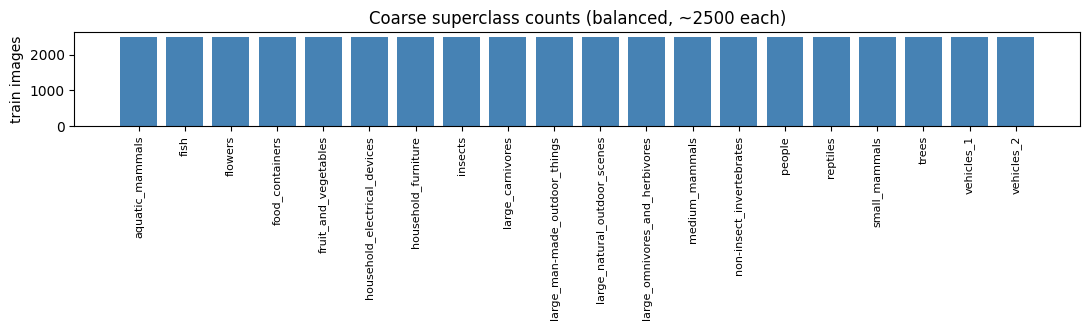

In [5]:
counts = np.bincount(train_coarse, minlength=NUM_CLASSES)
plt.figure(figsize=(11, 3.4))
plt.bar(range(NUM_CLASSES), counts, color="steelblue")
plt.xticks(range(NUM_CLASSES), coarse_names, rotation=90, fontsize=8)
plt.ylabel("train images")
plt.title(f"Coarse superclass counts (balanced, ~{counts.mean():.0f} each)")
plt.tight_layout()
plt.show()

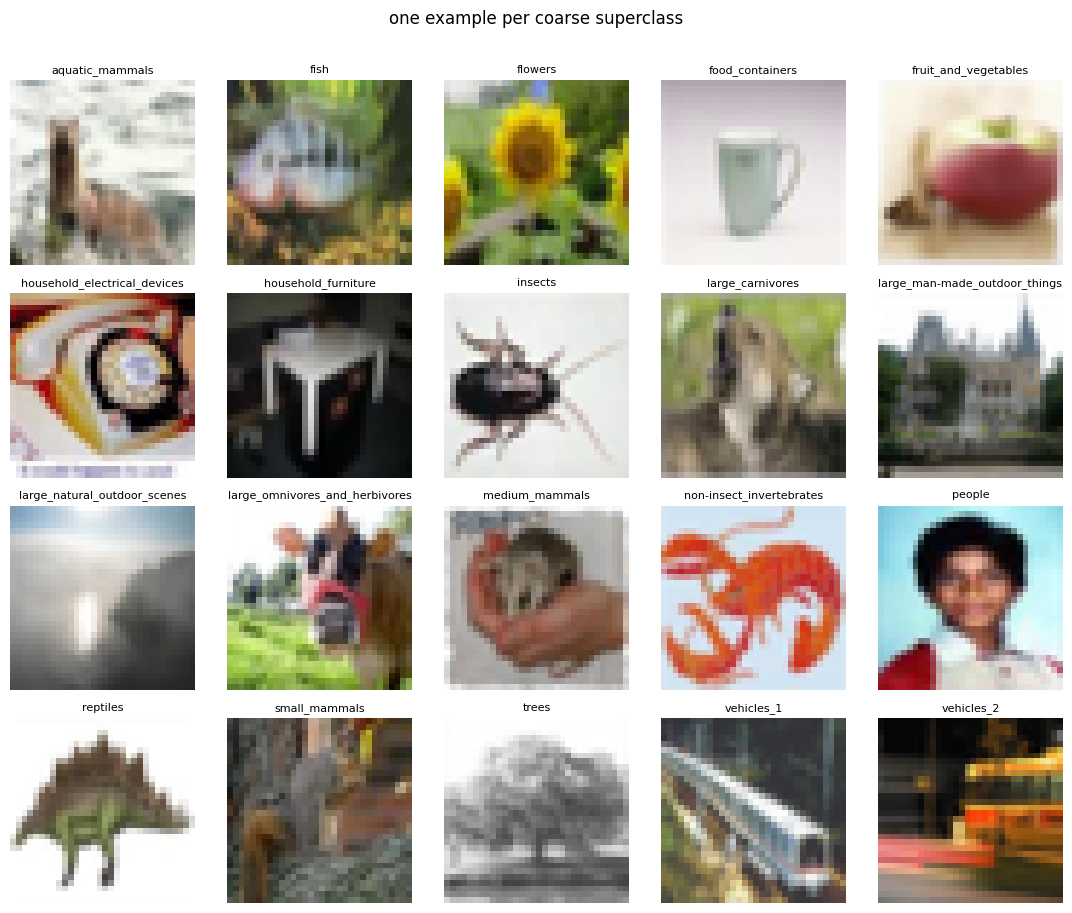

In [6]:
# One example image per superclass.
fig, axes = plt.subplots(4, 5, figsize=(11, 9))
for k, ax in enumerate(axes.ravel()):
    j = int(np.flatnonzero(train_coarse == k)[0])
    ax.imshow(train_images[j])
    ax.set_title(coarse_names[k], fontsize=8)
    ax.axis("off")
plt.suptitle("one example per coarse superclass", y=1.01)
plt.tight_layout()
plt.show()

## 4. Stratified Subset + Train/Validation Split

In [7]:
def stratified_subset(images, labels, *, subset_size, seed):
    if subset_size is None or subset_size >= labels.shape[0]:
        return images, labels
    rng = np.random.default_rng(seed)
    parts = []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        n_cls = min(max(1, round(subset_size * idx.size / labels.shape[0])), idx.size)
        parts.append(rng.choice(idx, size=n_cls, replace=False))
    sel = np.concatenate(parts)
    if sel.shape[0] > subset_size:
        sel = rng.choice(sel, size=subset_size, replace=False)
    rng.shuffle(sel)
    return images[sel], labels[sel]


def stratified_train_val_split(images, labels, *, val_fraction=0.1, seed=42):
    rng = np.random.default_rng(seed)
    tr, va = [], []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        rng.shuffle(idx)
        n_val = min(max(1, round(len(idx) * val_fraction)), max(len(idx) - 1, 1))
        va.append(idx[:n_val]); tr.append(idx[n_val:])
    tr, va = np.concatenate(tr), np.concatenate(va)
    rng.shuffle(tr); rng.shuffle(va)
    return images[tr], labels[tr], images[va], labels[va]

## 5. Spiral Serialization — the change

`build_spiral_index` lists the 1,024 pixel positions in outside→center spiral order. `to_sequence`
normalizes, reorders each image's pixels into that order, and reshapes to `(N, 32, 96)`: 32
timesteps, each a 32-pixel arc of the spiral. Identical to a row-by-row pipeline except for the
pixel order (swap `SPIRAL_IDX` for `np.arange(1024)` to get row-major back).


In [8]:
def build_spiral_index(n: int) -> np.ndarray:
    """Flat pixel indices (r*n + c) visited along an outside->center spiral."""
    order = []
    top, bottom, left, right = 0, n - 1, 0, n - 1
    while top <= bottom and left <= right:
        for c in range(left, right + 1):              # top row, left -> right
            order.append(top * n + c)
        top += 1
        for r in range(top, bottom + 1):              # right col, top -> bottom
            order.append(r * n + right)
        right -= 1
        if top <= bottom:
            for c in range(right, left - 1, -1):      # bottom row, right -> left
                order.append(bottom * n + c)
            bottom -= 1
        if left <= right:
            for r in range(bottom, top - 1, -1):      # left col, bottom -> top
                order.append(r * n + left)
            left += 1
    return np.asarray(order, dtype=np.int64)


SPIRAL_IDX = build_spiral_index(32)
assert SPIRAL_IDX.shape == (1024,) and np.array_equal(np.sort(SPIRAL_IDX), np.arange(1024)), \
    "spiral index is not a valid permutation of all pixels"


def to_sequence(images: np.ndarray) -> np.ndarray:
    """Normalize, reorder pixels along the spiral, reshape to (N, 32, 96)."""
    if images.ndim != 4 or images.shape[1:] != (32, 32, 3):
        raise ValueError(f"expected (N, 32, 32, 3); got {images.shape}")
    n = images.shape[0]
    flat = (images.astype(np.float32) / 255.0).reshape(n, 32 * 32, 3)   # row-major pixel order
    spiral = flat[:, SPIRAL_IDX, :]                                      # -> spiral order
    return spiral.reshape(n, 32, 96)


def make_sequence_pipeline(images, labels, *, batch_size, shuffle, shuffle_buffer=2048, seed=None):
    seq = to_sequence(images)
    ds = tf.data.Dataset.from_tensor_slices((seq, labels.astype(np.int64, copy=False)))
    if shuffle:
        ds = ds.shuffle(shuffle_buffer, seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

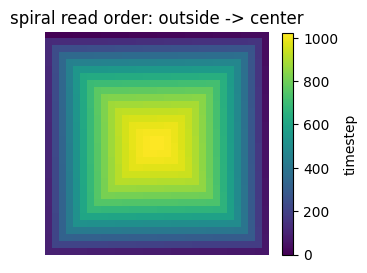

first 3 pixels (r,c): [(0, 0), (0, 1), (0, 2)]
last 3 pixels  (r,c): [(15, 16), (16, 16), (16, 15)]


In [9]:
# Read order: dark = read first (outer edge), bright = read last (center).
order_map = np.empty(32 * 32, dtype=np.int64)
order_map[SPIRAL_IDX] = np.arange(32 * 32)
plt.figure(figsize=(3.6, 3.6))
plt.imshow(order_map.reshape(32, 32), cmap="viridis")
plt.title("spiral read order: outside -> center")
plt.axis("off")
plt.colorbar(shrink=0.8, label="timestep")
plt.show()
print("first 3 pixels (r,c):", [(int(i) // 32, int(i) % 32) for i in SPIRAL_IDX[:3]])
print("last 3 pixels  (r,c):", [(int(i) // 32, int(i) % 32) for i in SPIRAL_IDX[-3:]])

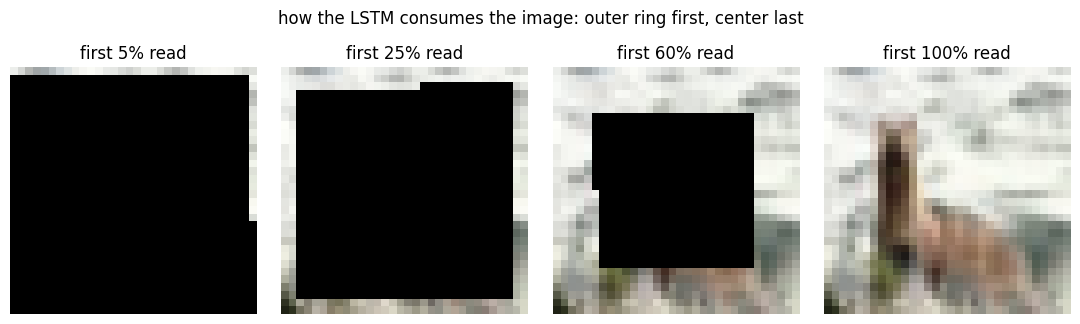

In [10]:
# What the LSTM has "seen" after reading the first X% of the spiral, on a real image.
def reveal_spiral(img01, frac):
    out_flat = img01.reshape(-1, 3).copy()
    k = int(frac * SPIRAL_IDX.shape[0])
    keep = np.zeros(out_flat.shape[0], dtype=bool)
    keep[SPIRAL_IDX[:k]] = True
    out_flat[~keep] = 0.0
    return out_flat.reshape(img01.shape)


sample = train_images[int(np.flatnonzero(train_coarse == 0)[0])].astype(np.float32) / 255.0
fracs = [0.05, 0.25, 0.60, 1.0]
fig, axes = plt.subplots(1, len(fracs), figsize=(11, 3.1))
for ax, f in zip(axes, fracs):
    ax.imshow(reveal_spiral(sample, f))
    ax.set_title(f"first {int(f * 100)}% read")
    ax.axis("off")
plt.suptitle("how the LSTM consumes the image: outer ring first, center last", y=1.03)
plt.tight_layout()
plt.show()

## 6. LSTM Model (20-way softmax)

In [11]:
keras = tf.keras
layers = tf.keras.layers


def build_lstm(num_classes=NUM_CLASSES, hidden_units=HIDDEN, dropout=DROPOUT) -> keras.Model:
    """LSTM over (32 timesteps, 96 features) -> softmax over coarse classes.

    tanh keeps the cuDNN fast path on GPU; dropout sits on the final state, not inside the cell.
    """
    inputs = keras.Input(shape=(32, 96), name="sequence")
    x = layers.LSTM(hidden_units, activation="tanh")(inputs)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="probs")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="spiral_lstm")


build_lstm().summary()

Model: "spiral_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence (InputLayer)           │ (None, 32, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,780 (460.08 KB)

 Trainable params: 117,780 (460.08 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train

In [12]:
img_tr, y_tr_s = stratified_subset(train_images, train_coarse, subset_size=SUBSET, seed=SEED)
x_tr, y_tr, x_val, y_val = stratified_train_val_split(img_tr, y_tr_s, val_fraction=0.1, seed=SEED)

train_ds = make_sequence_pipeline(x_tr, y_tr, batch_size=BATCH, shuffle=True, seed=SEED)
val_ds   = make_sequence_pipeline(x_val, y_val, batch_size=BATCH, shuffle=False)
test_ds  = make_sequence_pipeline(test_images, test_coarse, batch_size=BATCH, shuffle=False)
print(f"train {x_tr.shape[0]}  val {x_val.shape[0]}  test {test_images.shape[0]}  | {NUM_CLASSES} classes")

tf.keras.backend.clear_session()
model = build_lstm()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3")],
)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]
history = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2,
)

train 18000  val 2000  test 10000  | 20 classes
Epoch 1/30
141/141 - 17s - 121ms/step - accuracy: 0.1283 - loss: 2.8012 - top3: 0.3097 - val_accuracy: 0.1980 - val_loss: 2.6538 - val_top3: 0.3945 - learning_rate: 0.0010
Epoch 2/30
141/141 - 20s - 139ms/step - accuracy: 0.1851 - loss: 2.6420 - top3: 0.4014 - val_accuracy: 0.2030 - val_loss: 2.5921 - val_top3: 0.4250 - learning_rate: 0.0010
Epoch 3/30
141/141 - 15s - 103ms/step - accuracy: 0.2096 - loss: 2.5654 - top3: 0.4319 - val_accuracy: 0.2330 - val_loss: 2.4758 - val_top3: 0.4725 - learning_rate: 0.0010
Epoch 4/30
141/141 - 15s - 107ms/step - accuracy: 0.2265 - loss: 2.4979 - top3: 0.4531 - val_accuracy: 0.2475 - val_loss: 2.4307 - val_top3: 0.4695 - learning_rate: 0.0010
Epoch 5/30
141/141 - 14s - 100ms/step - accuracy: 0.2404 - loss: 2.4537 - top3: 0.4757 - val_accuracy: 0.2375 - val_loss: 2.4146 - val_top3: 0.4775 - learning_rate: 0.0010
Epoch 6/30
141/141 - 14s - 101ms/step - accuracy: 0.2511 - loss: 2.4137 - top3: 0.4906 - val

## 8. Training Curves

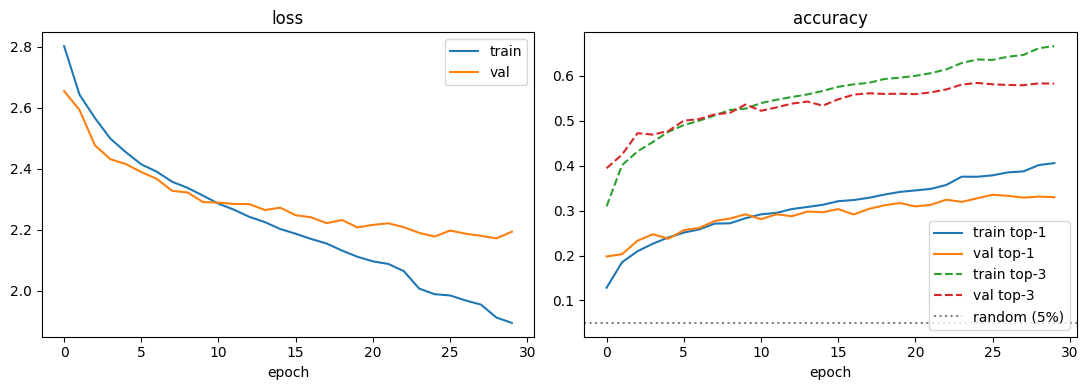

epochs actually run: 30


In [13]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(h["loss"], label="train")
ax[0].plot(h["val_loss"], label="val")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()

ax[1].plot(h["accuracy"], label="train top-1")
ax[1].plot(h["val_accuracy"], label="val top-1")
ax[1].plot(h["top3"], ls="--", label="train top-3")
ax[1].plot(h["val_top3"], ls="--", label="val top-3")
ax[1].axhline(1 / NUM_CLASSES, color="gray", ls=":", label="random (5%)")
ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout()
plt.show()
print(f"epochs actually run: {len(h['loss'])}")

## 9. Evaluate on the Test Set

In [14]:
y_prob = model.predict(test_ds, verbose=0)        # (N, 20)
y_pred = y_prob.argmax(axis=1)
y_true = test_coarse.astype(np.int64)
labels20 = list(range(NUM_CLASSES))

acc      = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
top3     = top_k_accuracy_score(y_true, y_prob, k=3, labels=labels20)
top5     = top_k_accuracy_score(y_true, y_prob, k=5, labels=labels20)
print(f"test accuracy : {acc:.3f}   (random = {1/NUM_CLASSES:.3f})")
print(f"macro F1      : {macro_f1:.3f}")
print(f"top-3 accuracy: {top3:.3f}")
print(f"top-5 accuracy: {top5:.3f}")

test accuracy : 0.326   (random = 0.050)
macro F1      : 0.320
top-3 accuracy: 0.579
top-5 accuracy: 0.712


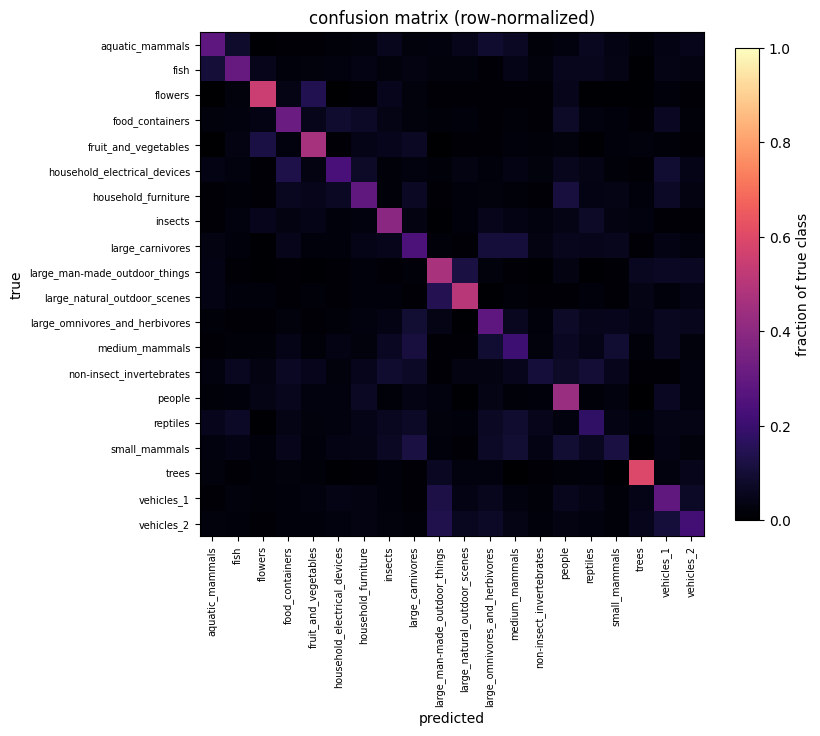

In [15]:
cm = confusion_matrix(y_true, y_pred, labels=labels20)
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
plt.figure(figsize=(8.5, 7.5))
plt.imshow(cmn, cmap="magma", vmin=0, vmax=1)
plt.colorbar(label="fraction of true class", shrink=0.85)
plt.xticks(range(NUM_CLASSES), coarse_names, rotation=90, fontsize=7)
plt.yticks(range(NUM_CLASSES), coarse_names, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true")
plt.title("confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

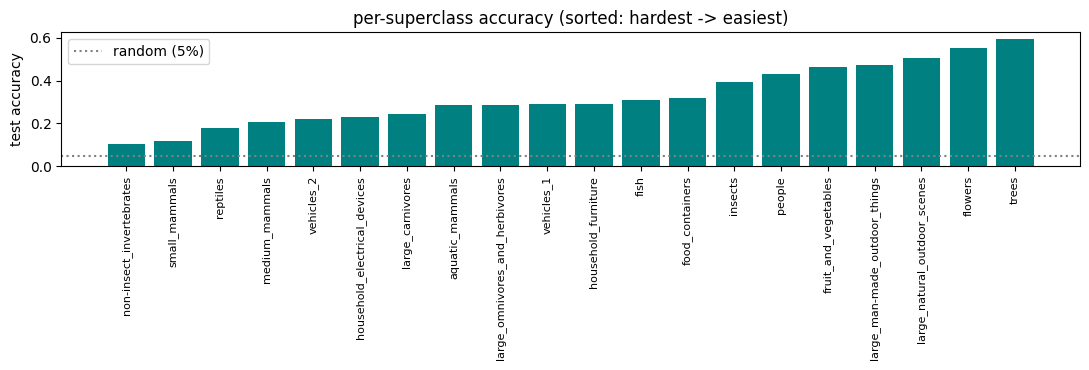

In [16]:
per_class = cm.diagonal() / cm.sum(axis=1).clip(min=1)
order = np.argsort(per_class)
plt.figure(figsize=(11, 3.8))
plt.bar(range(NUM_CLASSES), per_class[order], color="teal")
plt.xticks(range(NUM_CLASSES), [coarse_names[i] for i in order], rotation=90, fontsize=8)
plt.axhline(1 / NUM_CLASSES, color="gray", ls=":", label="random (5%)")
plt.ylabel("test accuracy")
plt.title("per-superclass accuracy (sorted: hardest -> easiest)")
plt.legend()
plt.tight_layout()
plt.show()

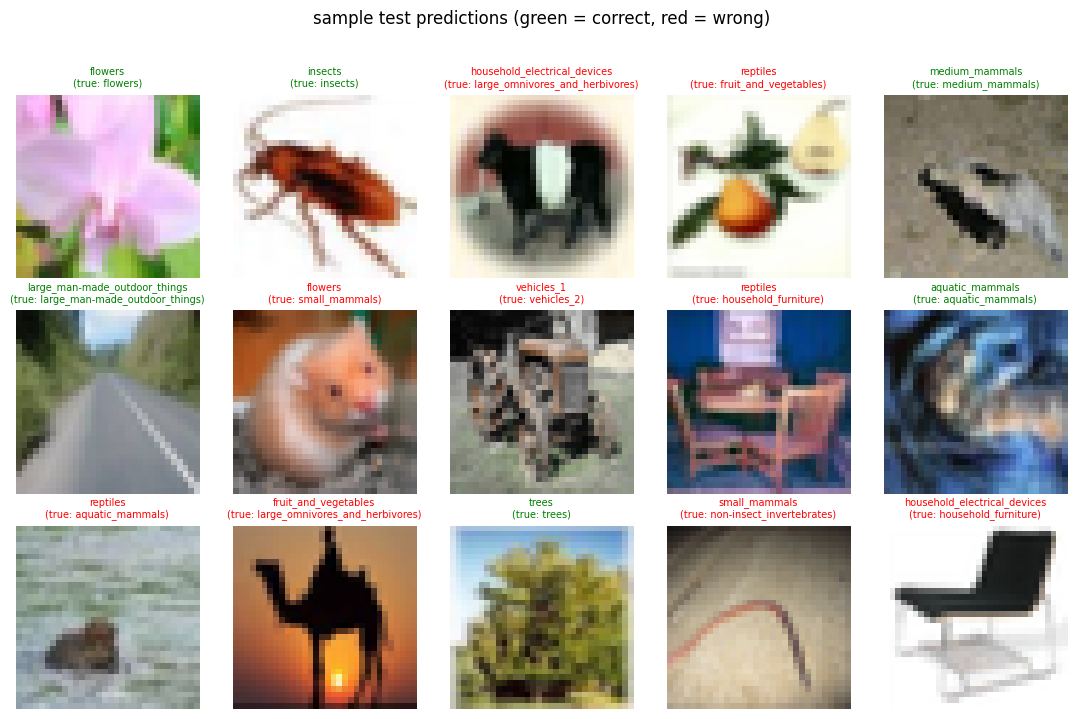

In [17]:
# Sample predictions: green title = correct, red = wrong.
rng = np.random.default_rng(0)
pick = rng.choice(len(test_images), size=15, replace=False)
fig, axes = plt.subplots(3, 5, figsize=(11, 7))
for ax, j in zip(axes.ravel(), pick):
    ax.imshow(test_images[j]); ax.axis("off")
    ok = y_pred[j] == y_true[j]
    ax.set_title(f"{coarse_names[y_pred[j]]}\n(true: {coarse_names[y_true[j]]})",
                 fontsize=7, color=("green" if ok else "red"))
plt.suptitle("sample test predictions (green = correct, red = wrong)", y=1.02)
plt.tight_layout()
plt.show()

## Interpretation

This is a real run on a balanced 20-way task, so read **top-1 accuracy** directly against the 5%
random floor, plus macro-F1 and the confusion matrix. A plain LSTM reading a serialized image is a
weak model — expect modest top-1 (well above 5% but far below a CNN), with **top-3/top-5
substantially higher**, meaning the model has real signal even when its first guess is wrong.

The confusion matrix and per-class bar show *where* it works: superclasses with a strong global
color/texture signature (the kind of thing that survives serialization) score best; fine-grained
categories blur together. The question the notebook exists to answer — does the outside→center
spiral order beat row-by-row? — is one edit away: set `SPIRAL_IDX = np.arange(1024)`, rerun, and
compare these same plots.
